# M1 v2 — Détection de fraude par groupe de pairs (production)

**Orange Money | Koceila SALEM**

## Refonte fondée sur l'état de l'art (vs M1 v1)
M1 v1 produisait 30% d'alertes (ingérable) car il comparait chaque compte à
TOUTE la population → les gros comptes techniques ressortaient par construction.

**M1 v2 applique les pratiques de production :**
1. **Segmentation par groupe de pairs** (bandes de volume) → un compte est jugé
   vs ses semblables, pas vs un particulier. Réduit massivement les faux positifs.
2. **Exclusion des features de fuite** (cohérence M5 : soldes-après, statut, attempt)
3. **Ensemble** : Isolation Forest + écart au profil du pair group (2 signaux)
4. **Budget d'alertes** : top N/jour calé sur capacité analyste (pas 30%)
5. **Explicabilité** : raison de chaque alerte pour l'analyste

Références : ensemble semi-supervisé (XGBoost+IF, 6M tx), peer-group anomaly
detection (-40 à -60% faux positifs), seuils par archétype.

## CELLULE 0 — Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import joblib, json, time, warnings, gc
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

from src import config as cfg
from src.data_loader import load_parquet, load_columns, cast_numeric
from src.features import bloc_a_transaction, bloc_b_temporel, bloc_c_comportemental, bloc_d_contextuel
from src import utils

MODEL_DIR  = cfg.MODELS_DIR / 'M1_fraude'
OUTPUT_DIR = cfg.OUTPUTS_DIR / 'M1_fraude'
CKPT_DIR   = OUTPUT_DIR / '_checkpoints'
for d in (MODEL_DIR, OUTPUT_DIR, CKPT_DIR): d.mkdir(parents=True, exist_ok=True)
print('Imports OK')

Imports OK


## CELLULE 1 — Features (réutilise le checkpoint si présent)

In [2]:
def downcast(df):
    for c in df.select_dtypes(include=['float64']).columns: df[c]=df[c].astype('float32')
    for c in df.select_dtypes(include=['object']).columns:
        if df[c].nunique()/len(df) < 0.5: df[c]=df[c].astype('category')
    return df

CKPT = CKPT_DIR / 'features.parquet'
if CKPT.exists():
    print('Checkpoint features trouvé -> rechargement')
    df = pd.read_parquet(CKPT)
    print(f'Rechargé : {df.shape[0]:,} x {df.shape[1]}')
else:
    cols = load_columns('M1')
    df = cast_numeric(load_parquet(columns=cols))
    df = downcast(df).sort_values([cfg.COL_SENDER_ID, cfg.COL_DATE]).reset_index(drop=True)
    t=time.time()
    df = bloc_a_transaction.build(df); df = bloc_b_temporel.build(df)
    df = bloc_c_comportemental.build(df, verbose=True); df = bloc_d_contextuel.build(df)
    print(f'Features OK | {time.time()-t:.0f}s')
    for c in [c for c in df.columns if c.startswith('f_')]:
        if df[c].dtype=='float64': df[c]=df[c].astype('float32')
    df.to_parquet(CKPT, index=False)
gc.collect()

Chargé en 1.4s
Dimensions : 25,456,467 lignes × 19 colonnes
RAM        : 6.36 Go
Plage      : 2025-08-29 10:35:20 → 2025-09-30 23:59:59


Jours      : 32


  vélocité 7j OK | 33s


  profil compte OK | 554s


  762 ligne(s) __UNKNOWN__ neutralisée(s)
✅ Bloc C complet | 905s


Features OK | 913s


0

## CELLULE 2 — Exclusion des features de fuite (cohérence avec M5)

In [3]:
all_feats = [c for c in df.columns if c.startswith('f_')]

# Features connues seulement APRÈS la transaction = fuite pour de la détection
FUITE = [c for c in all_feats if any(k in c for k in
    ['incoherence','delta_solde','solde_apres','statut','has_error','attempt'])]
FEATURE_COLS = [c for c in all_feats if c not in FUITE]
print(f'Features exclues (fuite) : {len(FUITE)}')
for f in FUITE: print(f'  - {f}')
print(f'\nFeatures retenues : {len(FEATURE_COLS)}')
print('Toutes connues AVANT/PENDANT la transaction (pas de fuite a posteriori)')

Features exclues (fuite) : 13
  - f_delta_solde
  - f_log_incoherence
  - f_solde_apres_nul
  - f_incoherence_recvr
  - f_statut_A1
  - f_statut_TF
  - f_statut_TI
  - f_statut_TPI
  - f_statut_TS
  - f_has_error
  - f_attempt_No Response
  - f_attempt_Request Cancelled
  - f_attempt_Request Confirmed

Features retenues : 36
Toutes connues AVANT/PENDANT la transaction (pas de fuite a posteriori)


## CELLULE 3 — Segmentation par groupe de pairs (bandes de volume)

Chaque compte est classé selon son volume d'activité. Un compte ne sera comparé
qu'à ses pairs de même bande → les gros comptes techniques ne sont plus des
anomalies par construction.

In [4]:
# Volume d'activité par compte émetteur
vol_compte = df.groupby(cfg.COL_SENDER_ID, observed=True).size().rename('vol_compte')
df = df.merge(vol_compte, left_on=cfg.COL_SENDER_ID, right_index=True, how='left')

# Bandes de volume robustes : seuils fixes métier (gère les volumes discrets)
# faible: 1-10 tx | moyen: 11-100 | élevé: 101-1000 | technique: >1000
def segmenter(v):
    if v <= 10: return 'faible'
    elif v <= 100: return 'moyen'
    elif v <= 1000: return 'eleve'
    else: return 'technique'
df['SEGMENT'] = df['vol_compte'].apply(segmenter)

# Si un segment est trop petit (<100 tx), le fusionner avec le précédent
tailles = df['SEGMENT'].value_counts()
print('Répartition des transactions par segment :')
print(tailles.to_string())
print('\nVolume (nb tx/compte) par segment :')
print(df.groupby('SEGMENT', observed=True)['vol_compte'].agg(['min','median','max']).to_string())
print('\nLe compte PT à 387k tx sera dans "technique" et comparé à ses pairs,')
print('pas à un particulier -> plus de faux positif structurel.')

Répartition des transactions par segment :
SEGMENT
moyen        10209253
eleve         7845186
technique     4803242
faible        2598786

Volume (nb tx/compte) par segment :


            min  median     max
SEGMENT                        
eleve       101   307.0    1000
faible        1     5.0      10
moyen        11    38.0     100
technique  1001  2265.0  387391

Le compte PT à 387k tx sera dans "technique" et comparé à ses pairs,
pas à un particulier -> plus de faux positif structurel.


## CELLULE 4 — Détection par segment (Isolation Forest entraîné par bande)

In [5]:
# Forcer toutes les features en numérique (le downcast a pu en passer en category)
for c in FEATURE_COLS:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Préparer X (imputation médiane numérique + suppression constantes)
X_df = df[FEATURE_COLS].astype('float32').copy()
X_df = X_df.fillna(X_df.median(numeric_only=True))
const = [c for c in FEATURE_COLS if X_df[c].std()==0]
if const:
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in const]; X_df = X_df[FEATURE_COLS]
    print(f'Constantes retirées : {const}')

df['iso_score'] = np.nan
scalers, modeles = {}, {}

for seg in df['SEGMENT'].unique():
    mask = (df['SEGMENT']==seg).values
    n = mask.sum()
    if n < 100:
        df.loc[mask,'iso_score'] = 0; continue
    Xs = RobustScaler()
    Xseg = Xs.fit_transform(X_df[mask]).astype(np.float32)
    iso = IsolationForest(n_estimators=200, contamination=0.02,
                          random_state=cfg.RANDOM_SEED, n_jobs=-1)
    iso.fit(Xseg)
    df.loc[mask,'iso_score'] = iso.score_samples(Xseg)
    scalers[seg]=Xs; modeles[seg]=iso
    print(f'  Segment {seg:12} : {n:>10,} tx | IF entraîné')
    del Xseg; gc.collect()
print('Détection par segment terminée')

  Segment faible       :  2,598,786 tx | IF entraîné


  Segment eleve        :  7,845,186 tx | IF entraîné


  Segment moyen        : 10,209,253 tx | IF entraîné


  Segment technique    :  4,803,242 tx | IF entraîné
Détection par segment terminée


## CELLULE 5 — 2e signal : écart au profil du pair group (ensemble)

In [6]:
# Z-score du montant DANS le segment (un montant énorme pour un particulier
# est suspect, mais normal pour un marchand)
df['montant_z_segment'] = df.groupby('SEGMENT', observed=True)[cfg.COL_MONTANT]\
    .transform(lambda x: (x - x.median()) / (x.std() + 1e-9))

# Score d'écart comportemental : combiner vélocité et montant vs pairs
df['ecart_pairs'] = df['montant_z_segment'].abs().clip(0, 10)

# ENSEMBLE : score IF (inversé en 0-100 par segment) + écart aux pairs
# Les deux signaux doivent concorder pour une alerte fiable
df['iso_risk'] = df.groupby('SEGMENT', observed=True)['iso_score']\
    .transform(lambda s: (-s).rank(pct=True) * 100)  # percentile INTRA-segment
df['ecart_risk'] = df.groupby('SEGMENT', observed=True)['ecart_pairs']\
    .transform(lambda s: s.rank(pct=True) * 100)

# Score combiné : moyenne pondérée (IF dominant, écart en confirmation)
df['RISK_SCORE'] = 0.7*df['iso_risk'] + 0.3*df['ecart_risk']
print('Score de risque combiné (ensemble IF + écart pairs) :')
print(df['RISK_SCORE'].describe(percentiles=[.5,.9,.99]).round(1).to_string())

Score de risque combiné (ensemble IF + écart pairs) :


count    25456467.0
mean           50.0
std            24.0
min             1.4
50%            50.1
90%            83.0
99%            97.2
max           100.0


## CELLULE 6 — Budget d'alertes (top N/jour, pas 30%)

In [7]:
# CAPACITÉ ANALYSTE : nb d'alertes traitables par jour (à ajuster selon l'équipe)
BUDGET_JOUR = 200
df['_jour'] = df[cfg.COL_DATE].dt.date
n_jours = df['_jour'].nunique()
budget_total = BUDGET_JOUR * n_jours

# Garder les top scores par jour (file priorisée gérable)
df['rang_jour'] = df.groupby('_jour')['RISK_SCORE'].rank(method='first', ascending=False)
df['ALERTE'] = (df['rang_jour'] <= BUDGET_JOUR).astype(int)

n_alertes = df['ALERTE'].sum()
print(f'=== BUDGET D ALERTES ===')
print(f'Capacité : {BUDGET_JOUR} alertes/jour x {n_jours} jours = {budget_total:,} max')
print(f'Alertes générées : {n_alertes:,} ({n_alertes/len(df)*100:.3f}% des transactions)')
print(f'\nComparaison M1 v1 : 7,636,941 alertes (30%)')
print(f'M1 v2 : {n_alertes:,} alertes ({n_alertes/len(df)*100:.2f}%) -> GÉRABLE')

print('\nRépartition des alertes par segment :')
print(df[df['ALERTE']==1]['SEGMENT'].value_counts().to_string())

=== BUDGET D ALERTES ===
Capacité : 200 alertes/jour x 32 jours = 6,400 max
Alertes générées : 6,202 (0.024% des transactions)

Comparaison M1 v1 : 7,636,941 alertes (30%)
M1 v2 : 6,202 alertes (0.02%) -> GÉRABLE

Répartition des alertes par segment :
SEGMENT
moyen        3677
eleve        1082
technique     768
faible        675


## CELLULE 7 — Explicabilité : raison de chaque alerte

In [8]:
alertes = df[df['ALERTE']==1].copy()

# Pour chaque alerte, identifier la raison principale
def raison(row):
    raisons = []
    if row['montant_z_segment'] > 3: raisons.append('montant tres elevé vs pairs')
    if row.get('f_velocite_7j',0) > df['f_velocite_7j'].quantile(0.99): raisons.append('vélocité anormale')
    if row.get('f_taux_echec_hist',0) > 0.5: raisons.append('historique d échec élevé')
    if row.get('f_montant_tres_arrondi',0)==1: raisons.append('montant tres arrondi')
    if row.get('f_est_nuit',0)==1: raisons.append('transaction nocturne')
    return ' + '.join(raisons) if raisons else 'profil globalement atypique'

alertes['RAISON'] = alertes.apply(raison, axis=1)
print('Top raisons d alerte :')
print(alertes['RAISON'].value_counts().head(10).to_string())

print('\n=== TOP 15 ALERTES PRIORITAIRES ===')
cols_show = [cfg.COL_SENDER_ID, cfg.COL_MONTANT, 'SEGMENT', 'RISK_SCORE', 'RAISON']
cols_show = [c for c in cols_show if c in alertes.columns]
print(alertes.nlargest(15,'RISK_SCORE')[cols_show].to_string(index=False))

Top raisons d alerte :
RAISON
montant tres elevé vs pairs + montant tres arrondi                               3880
montant tres arrondi                                                              847
montant tres elevé vs pairs                                                       713
profil globalement atypique                                                       418
historique d échec élevé                                                           62
montant tres elevé vs pairs + historique d échec élevé + montant tres arrondi      59
montant tres arrondi + transaction nocturne                                        52
historique d échec élevé + montant tres arrondi                                    41
transaction nocturne                                                               38
montant tres elevé vs pairs + montant tres arrondi + transaction nocturne          34

=== TOP 15 ALERTES PRIORITAIRES ===
      SENDER_USER_ID  TRANSACTION_AMOUNT SEGMENT  RISK_SCORE             

## CELLULE 8 — Visualisations

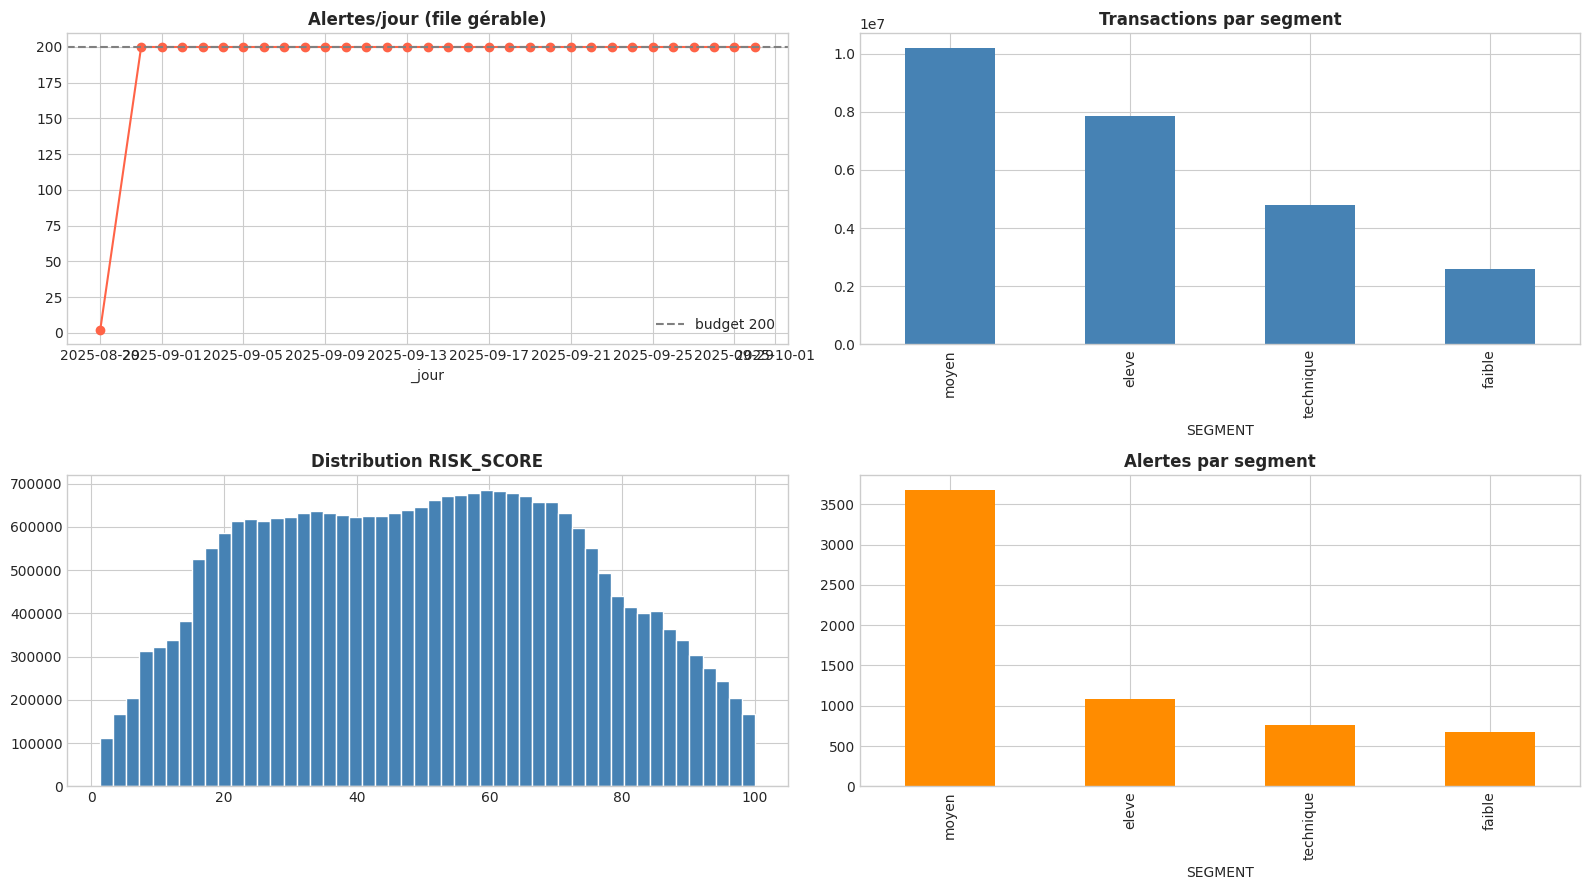

In [9]:
fig, axes = plt.subplots(2,2,figsize=(16,9))
# 1. Alertes par jour (doit être ~BUDGET_JOUR, lissé)
df[df['ALERTE']==1].groupby('_jour').size().plot(ax=axes[0,0], marker='o', color='tomato')
axes[0,0].axhline(BUDGET_JOUR, ls='--', color='gray', label=f'budget {BUDGET_JOUR}')
axes[0,0].set_title('Alertes/jour (file gérable)', fontweight='bold'); axes[0,0].legend()
# 2. Répartition par segment
df['SEGMENT'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Transactions par segment', fontweight='bold')
# 3. Distribution RISK_SCORE
axes[1,0].hist(df['RISK_SCORE'], bins=50, color='steelblue', edgecolor='white')
axes[1,0].set_title('Distribution RISK_SCORE', fontweight='bold')
# 4. Alertes par segment
alertes['SEGMENT'].value_counts().plot(kind='bar', ax=axes[1,1], color='darkorange')
axes[1,1].set_title('Alertes par segment', fontweight='bold')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'m1v2_analyse.png', dpi=150); plt.show()

## CELLULE 9 — Export (modèles par segment + alertes)

In [10]:
# Sauvegarder un modèle + scaler PAR segment
for seg in modeles:
    joblib.dump(modeles[seg], MODEL_DIR/f'iforest_{seg}.pkl')
    joblib.dump(scalers[seg], MODEL_DIR/f'scaler_{seg}.pkl')

params = {
    'version': 'v2 - peer group + budget alertes',
    'FEATURE_COLS': FEATURE_COLS, 'features_fuite_exclues': FUITE,
    'segments': list(modeles.keys()),
    'budget_jour': BUDGET_JOUR, 'contamination': 0.02,
    'poids_ensemble': {'iso':0.7,'ecart_pairs':0.3},
    'n_transactions': int(len(df)), 'n_alertes': int(n_alertes),
}
with open(MODEL_DIR/'params_v2.json','w') as f:
    json.dump(params, f, indent=2, default=str)

# Export alertes (file analyste priorisée)
exp = [cfg.COL_TRANSFER_ID, cfg.COL_DATE, cfg.COL_SENDER_ID, cfg.COL_MONTANT,
       cfg.COL_SERVICE, 'SEGMENT', 'RISK_SCORE', 'RAISON']
exp = [c for c in exp if c in alertes.columns]
alertes.nlargest(min(len(alertes),50000),'RISK_SCORE')[exp]\
    .to_csv(OUTPUT_DIR/'alertes_v2.csv', index=False, encoding='utf-8-sig')

# Dataset scoré complet (pour dashboard)
exp_full = exp + ['ALERTE','iso_risk','ecart_risk']
exp_full = [c for c in exp_full if c in df.columns]
df[exp_full].to_parquet(OUTPUT_DIR/'scored_v2.parquet', index=False)

print('Exports créés :')
print(f'  {len(modeles)} modèles par segment + scalers')
print('  alertes_v2.csv (file priorisée) + scored_v2.parquet')
print(f'\n=== RÉSUMÉ M1 v2 ===')
print(f'Transactions : {len(df):,}')
print(f'Segments     : {list(modeles.keys())}')
print(f'Alertes      : {n_alertes:,} ({n_alertes/len(df)*100:.2f}%) — vs 30% en v1')
print(f'Features     : {len(FEATURE_COLS)} (fuite exclue)')

Exports créés :
  4 modèles par segment + scalers
  alertes_v2.csv (file priorisée) + scored_v2.parquet

=== RÉSUMÉ M1 v2 ===
Transactions : 25,456,467
Segments     : ['faible', 'eleve', 'moyen', 'technique']
Alertes      : 6,202 (0.02%) — vs 30% en v1
Features     : 36 (fuite exclue)
